# 🐷 Pig Posture Recognition – Training

**Model:** EfficientNet-B4 (pretrained on ImageNet via `timm`)  
**Task:** 5-class posture classification from cropped pig bounding boxes  
**Metric:** Macro-averaged F1 score  

## Classes
| ID | Name |
|----|------|
| 0  | Lateral_lying_left |
| 1  | Lateral_lying_right |
| 2  | Sitting |
| 3  | Standing |
| 4  | Sternal_lying |

## ⚙️ Configuration
**Edit the paths and hyperparameters here before running.**

In [20]:
# ──────────────────────────────────────────────
# CONFIGURATION  (edit before running)
# ──────────────────────────────────────────────

# Which training set to use: "T1" or "T2"
TAG = "T2"

# Paths – relative to this notebook's location
DATA_ROOT = "/datasets/multi-view-pig-posture-recognition"

if TAG == "T1":
    CSV_PATH = f"{DATA_ROOT}/train1.csv"
    IMG_DIR  = f"{DATA_ROOT}/train1_images"
else:  # T2
    CSV_PATH = f"{DATA_ROOT}/train2.csv"
    IMG_DIR  = f"{DATA_ROOT}/train2_images"

OUTPUT_DIR = f"runs/{TAG.lower()}"        # checkpoints + logs saved here

# Optionally fine-tune from a T1 checkpoint when training T2:
# PRETRAINED_CKPT = "runs/t1/best_model.pth"   # <-- uncomment if desired
PRETRAINED_CKPT = None

# Hyperparameters
MODEL_NAME     = "efficientnet_b4"   # any timm model, e.g. convnext_small
IMG_SIZE       = 224
BATCH_SIZE     = 64
EPOCHS         = 10
LR             = 3e-4
VAL_FRAC       = 0.10                # fraction held out for validation
LABEL_SMOOTH   = 0.10
MIXUP_ALPHA    = 0.20                # set 0 to disable Mixup
PAD_RATIO      = 0.15                # contextual padding around each bbox crop
NUM_WORKERS    = 8
SEED           = 42

NUM_CLASSES    = 5
CLASS_NAMES    = ["Lateral_lying_left", "Lateral_lying_right",
                  "Sitting", "Standing", "Sternal_lying"]

print(f"Tag: {TAG}  |  CSV: {CSV_PATH}  |  Output: {OUTPUT_DIR}")

Tag: T2  |  CSV: /datasets/multi-view-pig-posture-recognition/train2.csv  |  Output: runs/t2


## 📦 Install Dependencies

In [21]:
# Run this cell once on a fresh environment
# For GPU servers with CUDA 12.x:
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121
# For CUDA 11.8:
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118

!pip install timm tqdm scikit-learn pandas pillow -q

## 📚 Imports

In [22]:
import os, ast, random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.notebook import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms as T
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

import warnings
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla V100-SXM2-32GB
VRAM: 33.8 GB


## 🔒 Reproducibility

In [23]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Seed set to {SEED}. Output dir: {OUTPUT_DIR}")

Seed set to 42. Output dir: runs/t2


## 🔍 Exploratory Data Analysis

In [24]:
df = pd.read_csv(CSV_PATH)
print(f"Total instances: {len(df)}")
print(f"Unique images:   {df['image_id'].nunique()}")
print(f"\nColumns: {list(df.columns)}")
df.head(3)

Total instances: 23450
Unique images:   3150

Columns: ['row_id', 'image_id', 'width', 'height', 'bbox', 'class_id']


,row_id,image_id,width,height,bbox,class_id
0,train_pen1_orb_cam1_20250108_085204_0000,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5,368.0,349.0,435.0]",0
1,train_pen1_orb_cam1_20250108_085204_0001,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5,428.0,233.0,438.0]",4
2,train_pen1_orb_cam1_20250108_085204_0002,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0,137.5,342.0,198.0]",1


In [25]:
import os
print("CWD:", os.getcwd())

# Check if the datasets folder exists at all
for root, dirs, files in os.walk("datasets"):
    for f in files:
        if f.endswith(".csv"):
            print(os.path.join(root, f))

CWD: /home/jovyan/work/notebooks/Maschine learning/Neuronale netzwerke/Mittelstufenprojekt/Mittelstufenprojekt/Mittelstufenprojekt/Fabian


In [26]:
print("\nClass distribution:")
for c in range(NUM_CLASSES):
    cnt = (df["class_id"] == c).sum()
    bar = "█" * int(30 * cnt / len(df))
    print(f"  {c} - {CLASS_NAMES[c]:<22} {bar:<30} {cnt:>5}  ({100*cnt/len(df):.1f}%)")


Class distribution:
  0 - Lateral_lying_left     ███                             3083  (13.1%)
  1 - Lateral_lying_right    ████                            3435  (14.6%)
  2 - Sitting                                                 695  (3.0%)
  3 - Standing               ████████████                    9928  (42.3%)
  4 - Sternal_lying          ████████                        6309  (26.9%)


## 🗂️ Dataset & Transforms

In [27]:
class PigPostureDataset(Dataset):
    """
    Crops each pig from the full frame using its bounding box.
    bbox format: [xmin, ymin, w, h]
    """
    def __init__(self, df, img_dir, transform=None, pad_ratio=0.15):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform
        self.pad_ratio = pad_ratio

    def __len__(self): return len(self.df)

    def _crop(self, img, bbox):
        W, H = img.size
        x, y, w, h = [float(v) for v in ast.literal_eval(bbox)]
        px, py = w * self.pad_ratio, h * self.pad_ratio
        x1 = max(0, int(x - px));  y1 = max(0, int(y - py))
        x2 = min(W, int(x+w+px)); y2 = min(H, int(y+h+py))
        return img.crop((x1, y1, x2, y2))

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(os.path.join(self.img_dir, row["image_id"])).convert("RGB")
        crop  = self._crop(img, row["bbox"])
        if self.transform: crop = self.transform(crop)
        return crop, int(row["class_id"])


def get_train_transform(size=IMG_SIZE):
    return T.Compose([
        T.Resize((size + 32, size + 32)),
        T.RandomCrop(size),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomVerticalFlip(p=0.2),
        T.RandomRotation(degrees=15),
        T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.05),
        T.RandomGrayscale(p=0.05),
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        T.RandomErasing(p=0.25, scale=(0.02, 0.15)),
    ])

def get_val_transform(size=IMG_SIZE):
    return T.Compose([
        T.Resize((size, size)),
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

print("Dataset and transforms defined.")

Dataset and transforms defined.


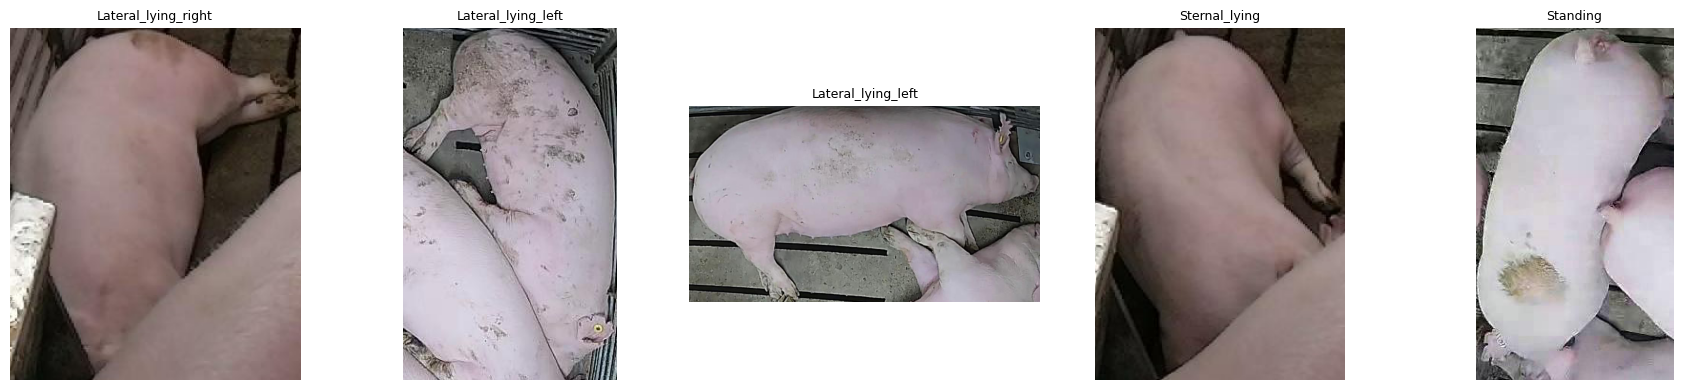

In [28]:
# Preview: show 5 random crops from the dataset
import matplotlib.pyplot as plt

sample_df = df.sample(5, random_state=0)
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, (_, row) in zip(axes, sample_df.iterrows()):
    img  = Image.open(os.path.join(IMG_DIR, row["image_id"])).convert("RGB")
    x, y, w, h = ast.literal_eval(row["bbox"])
    crop = img.crop((int(x), int(y), int(x+w), int(y+h)))
    ax.imshow(crop)
    ax.set_title(CLASS_NAMES[int(row["class_id"])], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## ✂️ Train / Validation Split

In [29]:
train_df, val_df = train_test_split(
    df, test_size=VAL_FRAC, stratify=df["class_id"], random_state=SEED
)
print(f"Train: {len(train_df)}  |  Val: {len(val_df)}")

train_ds = PigPostureDataset(train_df, IMG_DIR, transform=get_train_transform())
val_ds   = PigPostureDataset(val_df,   IMG_DIR, transform=get_val_transform())

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
print("DataLoaders ready.")

Train: 21105  |  Val: 2345
DataLoaders ready.


## 🧠 Model, Loss & Optimizer

In [30]:
# ── Build model ───────────────────────────────────────────────────────────────
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES)

if PRETRAINED_CKPT and os.path.isfile(PRETRAINED_CKPT):
    state = torch.load(PRETRAINED_CKPT, map_location="cpu")
    model.load_state_dict(state["model"])
    print(f"Loaded checkpoint: {PRETRAINED_CKPT}")

model = model.to(DEVICE)
total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Model: {MODEL_NAME}  |  Parameters: {total_params:.1f}M")

# ── Class-weighted loss ───────────────────────────────────────────────────────
counts  = Counter(train_df["class_id"].tolist())
total   = len(train_df)
weights = torch.tensor(
    [total / (NUM_CLASSES * max(counts.get(c, 1), 1)) for c in range(NUM_CLASSES)],
    dtype=torch.float32
).to(DEVICE)
print("Class weights:", [f"{w:.2f}" for w in weights.cpu()])

criterion       = nn.CrossEntropyLoss(weight=weights, label_smoothing=LABEL_SMOOTH)
criterion_plain = nn.CrossEntropyLoss(weight=weights)   # used inside Mixup

# ── Optimizer & Scheduler ─────────────────────────────────────────────────────
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler    = GradScaler()
print("Optimizer and scheduler ready.")

Model: efficientnet_b4  |  Parameters: 17.6M
Class weights: ['1.52', '1.37', '6.74', '0.47', '0.74']
Optimizer and scheduler ready.


## 🛠️ Helper Functions

In [31]:
def mixup_data(x, y, alpha=0.2):
    """Apply Mixup augmentation."""
    if alpha <= 0: return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0)).to(x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

def mixup_loss(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


def train_one_epoch(model, loader, optimizer, scaler):
    model.train()
    loss_sum, preds_all, labels_all = 0.0, [], []
    for imgs, labels in tqdm(loader, desc="  Train", leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        imgs, y_a, y_b, lam = mixup_data(imgs, labels, alpha=MIXUP_ALPHA)
        optimizer.zero_grad()
        with autocast():
            logits = model(imgs)
            loss   = mixup_loss(criterion_plain, logits, y_a, y_b, lam)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()
        loss_sum += loss.item() * imgs.size(0)
        preds_all.extend(logits.argmax(1).cpu().numpy())
        labels_all.extend(y_a.cpu().numpy())
    n = len(loader.dataset)
    return loss_sum / n, f1_score(labels_all, preds_all, average="macro", zero_division=0)


@torch.no_grad()
def validate_epoch(model, loader):
    model.eval()
    loss_sum, preds_all, labels_all = 0.0, [], []
    for imgs, labels in tqdm(loader, desc="  Val  ", leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with autocast():
            logits = model(imgs)
            loss   = criterion(logits, labels)
        loss_sum += loss.item() * imgs.size(0)
        preds_all.extend(logits.argmax(1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())
    n = len(loader.dataset)
    return loss_sum / n, f1_score(labels_all, preds_all, average="macro", zero_division=0), preds_all, labels_all

print("Helper functions defined.")

Helper functions defined.


## 🚀 Training Loop

In [32]:
best_val_f1 = 0.0
log         = []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_f1            = train_one_epoch(model, train_loader, optimizer, scaler)
    val_loss, val_f1, _, _          = validate_epoch(model, val_loader)
    scheduler.step()
    lr = scheduler.get_last_lr()[0]

    mark = "★" if val_f1 > best_val_f1 else " "
    print(f"{mark} Epoch {epoch:03d}/{EPOCHS} | "
          f"Train  loss={train_loss:.4f} f1={train_f1:.4f} | "
          f"Val  loss={val_loss:.4f} f1={val_f1:.4f} | lr={lr:.2e}")

    log.append(dict(epoch=epoch, train_loss=train_loss, train_f1=train_f1,
                    val_loss=val_loss, val_f1=val_f1, lr=lr))

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        ckpt_path   = os.path.join(OUTPUT_DIR, "best_model.pth")
        torch.save({
            "epoch": epoch, "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "val_f1": val_f1, "model_name": MODEL_NAME, "tag": TAG,
        }, ckpt_path)
        print(f"  → Saved best model (val_f1={val_f1:.4f})")

print(f"\nTraining complete. Best Val F1: {best_val_f1:.4f}")
pd.DataFrame(log).to_csv(os.path.join(OUTPUT_DIR, "training_log.csv"), index=False)

  Train:   0%|          | 0/329 [00:00<?, ?it/s]

  Val  :   0%|          | 0/37 [00:00<?, ?it/s]

★ Epoch 001/10 | Train  loss=1.1592 f1=0.3585 | Val  loss=1.4297 f1=0.7121 | lr=2.93e-04
  → Saved best model (val_f1=0.7121)


  Train:   0%|          | 0/329 [00:00<?, ?it/s]

  Val  :   0%|          | 0/37 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/37 [00:00<?, ?it/s]

★ Epoch 009/10 | Train  loss=0.4077 f1=0.5556 | Val  loss=1.3078 f1=0.8964 | lr=8.32e-06
  → Saved best model (val_f1=0.8964)


  Train:   0%|          | 0/329 [00:00<?, ?it/s]

  Val  :   0%|          | 0/37 [00:00<?, ?it/s]

★ Epoch 010/10 | Train  loss=0.3983 f1=0.5800 | Val  loss=1.2836 f1=0.8996 | lr=1.00e-06
  → Saved best model (val_f1=0.8996)

Training complete. Best Val F1: 0.8996


## 📈 Training Curves

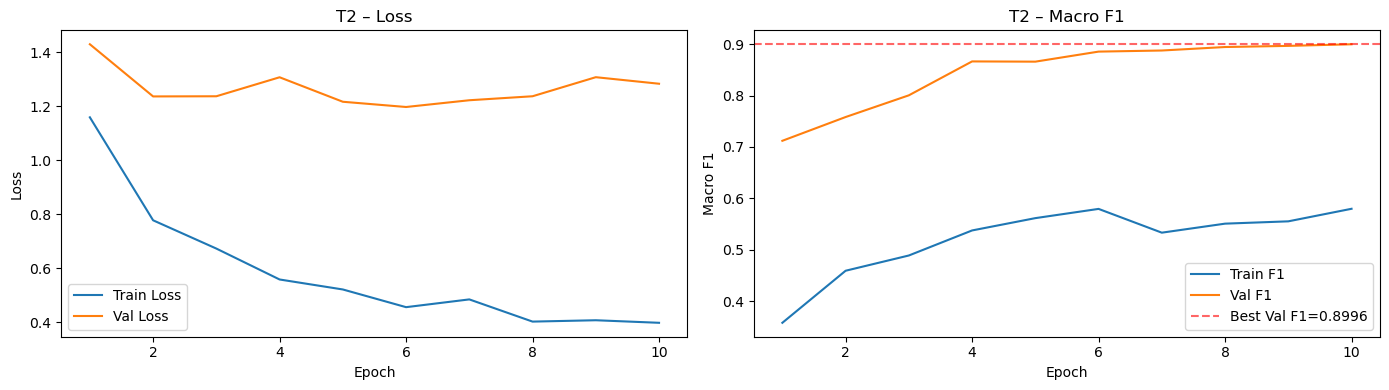

In [34]:
import matplotlib.pyplot as plt

log_df = pd.DataFrame(log)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(log_df["epoch"], log_df["train_loss"], label="Train Loss")
axes[0].plot(log_df["epoch"], log_df["val_loss"],   label="Val Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title(f"{TAG} – Loss"); axes[0].legend()

axes[1].plot(log_df["epoch"], log_df["train_f1"], label="Train F1")
axes[1].plot(log_df["epoch"], log_df["val_f1"],   label="Val F1")
axes[1].axhline(best_val_f1, color="red", linestyle="--", alpha=0.6, label=f"Best Val F1={best_val_f1:.4f}")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Macro F1")
axes[1].set_title(f"{TAG} – Macro F1"); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=120)
plt.show()

## 📊 Final Classification Report (Validation Set)

In [35]:
# Load best model and evaluate
best_ckpt = torch.load(os.path.join(OUTPUT_DIR, "best_model.pth"), map_location=DEVICE)
model.load_state_dict(best_ckpt["model"])

_, _, val_preds, val_labels = validate_epoch(model, val_loader)
print(classification_report(val_labels, val_preds, target_names=CLASS_NAMES))

  Val  :   0%|          | 0/37 [00:00<?, ?it/s]

                     precision    recall  f1-score   support

 Lateral_lying_left       0.87      0.93      0.90       308
Lateral_lying_right       0.90      0.95      0.93       344
            Sitting       0.74      0.84      0.79        69
           Standing       0.98      0.99      0.98       993
      Sternal_lying       0.94      0.87      0.90       631

           accuracy                           0.94      2345
          macro avg       0.89      0.91      0.90      2345
       weighted avg       0.94      0.94      0.94      2345

